In this exercise, you'll be working with a dataset containing information about passengers on the Titanic. You can get more information about this dataset [here](https://www.kaggle.com/competitions/titanic). Our goal will be to build a model to predict whether a passenger survived the voyage.

Let's start by building a model using Age as a predictor variable.

When performing a train/test split, you usually want to make sure that the ratios of target values look the same in the training set and in the test set. This is especially true with imbalanced targets, where there are more observations in one class than the other. This can be done by, instead of a completely random split, by performing a **stratified** split.

In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [335]:
titanic = pd.read_csv("../data/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1.  Create a DataFrame, X, which contains one column, Age, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split. 

In [336]:
predictors = ['Age']
target = 'Survived'

X = titanic[predictors]
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 321, stratify = y)

2. Now, try and fit a logistic regression model using the [LogisticRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). When you do this, you're likely to encounter an error, that "Input X contains NaN." If you check, you'll find that there are some missing values in the Age column. In the next step, we'll address this issue. 

In [337]:
from sklearn.linear_model import LogisticRegression

In [338]:
LogisticRegression().fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [339]:
X_train.isna().sum()

Age    123
dtype: int64

One option when a column contains missing values is to **impute** them, meaning to replace the missing values with an estimate. A simple way to impute is to fill missing values using the mean value. **Important Note:** When imputing with the mean, you should calculate the mean value only on the training data. In order to have an unbiased estimate of model performance, it is important that the model has access to no information about the test set.

In [340]:
X_train.mean()

Age    30.0185
dtype: float64

3. Using a [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html), fit the training data and then use it to transform both the training and test data.

In [341]:
from sklearn.impute import SimpleImputer

In [342]:
impute_mean = SimpleImputer(strategy='mean' ).fit(X_train)

X_train_imputed= impute_mean.transform(X_train)
X_test_imputed = impute_mean.transform(X_test)

4. Now, fit your logistic regression model to the training data and generate predictions on the test data.

In [343]:
#fit a model with mean imputed train dataset 
lgr_surv_model= LogisticRegression().fit(X_train_imputed, y_train)

In [344]:
#generating predictions on test data
y_pred = lgr_surv_model.predict(X_test_imputed)

There are multiple ways we can assess the performance of a classification model. A common way is put those predictions into a [confusion matrix](https://en.wikipedia.org/wiki/Confusion_matrix), which compares the predicted and actual values. 

5. Create a confusion matrix out of the predictions. What do you find?

In [345]:
#import confusion matrix from sklearn metrics
from sklearn.metrics import confusion_matrix

In [346]:
y_pred.shape

(268,)

In [347]:
confusion_matrix(y_test, y_pred)

array([[165,   0],
       [103,   0]])

In [348]:
y_test.value_counts()

Survived
0    165
1    103
Name: count, dtype: int64

I see 165 positive classes, 0 negative classes, 103 false positive classes and 0 false negative classes.
This tells that 165 not survived and 103 people survived.

6. Plot the ROC curve. How well does your model do? Hint: You can use the [RocCurveDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html) to create this plot.

In [349]:
#To display ROC curve import ROCcurve display  from sklearn metrics
from sklearn import metrics
from sklearn.metrics import RocCurveDisplay

In [350]:
#finding out the false positive rate, true positive rate and thresholds
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)

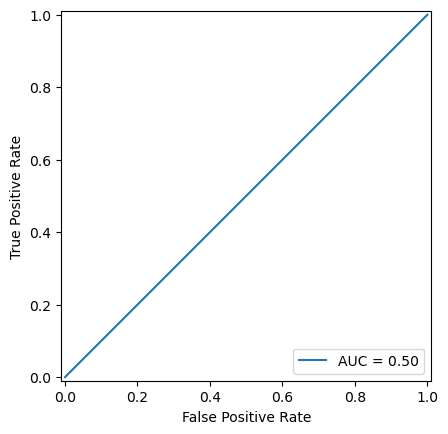

In [351]:
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.show()

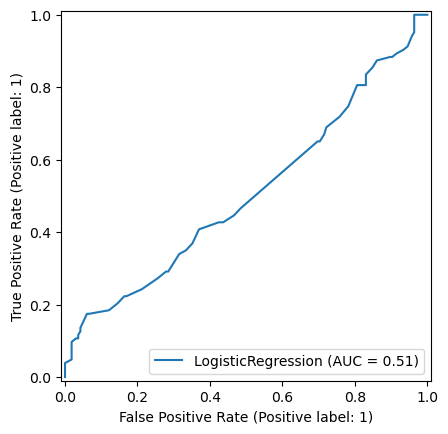

In [352]:
RocCurveDisplay.from_estimator(lgr_surv_model, X_test_imputed,y_test)

You are likely to see that the model does not tend to predict that individuals survived the voyage. Let's see if we can determine why.
7. Look at the average age of survivors vs. those that did not survive the voyage. What do you find?

In [353]:
titanic.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

The survivers average age is slightly lower than the non-survivors average age.

8. Perhaps the actual age number is as important as whether a passenger was a child or an adult. Create a Boolean column that indicates whether a passenger was a child or an adult. Pick a cutoff age and if they were less than this age, label as a child. We'll see later on how we can make choosing the age part of our model building pipeline, but for now, choose an age or do some calculations to pick an age that you think might do well.

In [354]:
titanic.loc[titanic['Age'] <= 18, 'child'] = 1
titanic.loc[titanic['Age'] > 18, 'child'] = 0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 321, stratify = y)

In [355]:
titanic['child'].isna().sum()

np.int64(177)

9. When imputing the missing values, you'll need to change the strategy from mean to most_frequent. Impute the missing values, then fit the model using this new variable, generate predictions, and view the confusion matrix. How did your model do?

In [356]:
impute_frequent = SimpleImputer(strategy='most_frequent').fit(X_train)
X_train_most_impute= impute_frequent.transform(X_train)
X_test_most_impute= impute_frequent.transform(X_test)

In [357]:
y_pred =  lgr_surv_model.predict(X_test_most_impute)

In [358]:
y_test.shape

(268,)

In [359]:
y_pred.shape

(268,)

In [360]:
confusion_matrix(y_test, y_pred)

array([[165,   0],
       [103,   0]])

Other common metrics for classification include accuracy, precision, and recall. For more information, see https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall. These metrics can be viewed using the [classification_report function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html). 

10. Generate a classification report for your model.

In [361]:
from sklearn.metrics import classification_report

In [365]:
print(classification_report(y_test, y_pred, zero_division='warn'))
              

              precision    recall  f1-score   support

           0       0.62      1.00      0.76       165
           1       0.00      0.00      0.00       103

    accuracy                           0.62       268
   macro avg       0.31      0.50      0.38       268
weighted avg       0.38      0.62      0.47       268



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Another important variable is the Sex variable. 

11. Create a DataFrame, X, which contains one column, Sex, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split. 

In [ ]:
predictors = ['Sex']
target = 'Survived'

X = titanic[predictors]
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 321, stratify = y)

If you inspect the Sex variable, you'll find that it is encoded as a string. We need to convert it to a numeric type so that our model can use it. We can do this using a [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

12. Fit a OneHotEncoder to the training data and then transform both the training and test sets. Fit a model and evaluate the performance of this model.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder().fit(X_train)

X_train_transformed= ohe.transform(X_train)
X_test_transformed= ohe.transform(X_test)

Notice how we have used different types of transformations, an imputer for the age-related variables and a OneHotEncoder for the Sex variable. When we need to use multiple types of transformations, a [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) is useful. 

In [ ]:
from sklearn.compose import ColumnTransformer

In the next part, we'll fit a model using both the Sex column and our column indicating whether the passenger was a child. 

13. Create a DataFrame, X, which contains two columns, Sex and the child indicator column, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split. Then create a ColumnTransformer which will apply a SimpleImputer to the child column and a OneHotEncoder to the Sex column. Fit it on the training data and then transform the test data. Then fit a model on this and see how well it does.

In [ ]:
predictors = ['Sex','child']
target = 'Survived'

X = titanic[predictors]
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 321, stratify = y)

In [ ]:
#create a columntransformer which will apply a SimpleImputer to the child column and a OneHotEncoder to the Sex column.
ct = ColumnTransformer(
    [("encode_sex", OneHotEncoder(drop='first') , ['Sex']),
     ("impute_child", SimpleImputer(),['child'])]
   )
#Fit the model on the training data and transform the test data
ct_model = ct.fit(X_train)
ct_train_transformed = ct_model.transform(X_train)
ct_test_transformed = ct_model.transform(X_test)

In [ ]:
#Fit a logistic regression model on the trasformed data
log_model = LogisticRegression()
log_model.fit(ct_train_transformed, y_train)
y_pred = log_model.predict(ct_test_transformed)

In [ ]:
confusion_matrix(y_test, y_pred)

In [ ]:
y_test.value_counts()

In [ ]:
print(classification_report(y_test,y_pred))

Based on the precision, recall and accuracy this model with two variables Sex and child indicator , it is doing decent job.

Finally, let's see how we can do all of this in a slightly more compact manner. We can use a [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) which allows us to specify preprocessing steps (like the ColumnTransformer we used earlier) as well as the model we want to fit. 

14. Create a Pipeline which contains the ColumnTransformer and the LogisticRegression model. 


In [ ]:
#import pipeline from sklearn
from sklearn.pipeline import Pipeline

In [ ]:
ct = ColumnTransformer(
    [("encode_sex", OneHotEncoder(drop='first') , ['Sex']),
     ("impute_child", SimpleImputer(),['child'])]
   )
# create a pipeline
pipe = Pipeline([('column_transfer', ct),
                ('model', LogisticRegression())])

In [ ]:
#fit the pipelinemodel on training data
pipe.fit(X_train,y_train)
#predict test data
y_pred_pipe = pipe.predict(X_test)
confusion_matrix(y_test,y_pred_pipe)


In [ ]:
print(classification_report(y_test,y_pred_pipe))